# Real-Time Crisis Detection System
## Notebook 06 — Evaluation & Explainability
**Goal:** Evaluate the XLM-RoBERTa classification model, compute SHAP feature importance for text predictions, and evaluate the credibility clustering pipeline.

In [3]:
import os, sys, warnings; warnings.filterwarnings('ignore')
IN_COLAB='google.colab' in sys.modules; IN_KAGGLE='KAGGLE_URL_BASE' in os.environ
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR='/content/drive/MyDrive/10Academy/crisis-detection-system'
elif IN_KAGGLE: PROJECT_DIR='/kaggle/working/crisis-detection-system'
else: PROJECT_DIR=os.path.abspath('..')
DATA_PROCESSED=f'{PROJECT_DIR}/data/processed'
MODELS_DIR=f'{PROJECT_DIR}/models'
OUTPUTS_DIR=f'{PROJECT_DIR}/outputs'
UTILS_DIR=f'{PROJECT_DIR}/utils'
os.makedirs(f'{OUTPUTS_DIR}/figures', exist_ok=True)
if UTILS_DIR not in sys.path: sys.path.insert(0, UTILS_DIR)
print(f' Ready. Project: {PROJECT_DIR}')

Mounted at /content/drive
 Ready. Project: /content/drive/MyDrive/10Academy/crisis-detection-system


In [4]:
!pip install -q shap transformers datasets scikit-learn seaborn matplotlib torch

In [5]:
# Load Classification Results & Ground Truth
import pandas as pd, numpy as np, pickle, torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

clf_path = f'{DATA_PROCESSED}/classified_events.csv'
df_clf = pd.read_csv(clf_path, index_col='post_id')

try:
    with open(f'{MODELS_DIR}/crisis_classifier/label_encoder.pkl', 'rb') as f:
        label_data = pickle.load(f)
    CLASS_NAMES = label_data['class_names']
except:
    CLASS_NAMES = ['flood','earthquake','fire','accident','violence','storm','other']

# Filter to only posts that had a ground truth label for evaluation
LABEL_MAP = {
    'flood': 'flood', 'banjir': 'flood', 'floods': 'flood',
    'earthquake': 'earthquake', 'gempa': 'earthquake',
    'fire': 'fire', 'kebakaran': 'fire', 'wildfire': 'fire',
    'accident': 'accident', 'kecelakaan': 'accident', 'crash': 'accident',
    'violence': 'violence', 'kekerasan': 'violence', 'riot': 'violence',
    'storm': 'storm', 'typhoon': 'storm', 'cyclone': 'storm', 'badai': 'storm',
    'volcano': 'other', 'landslide': 'other', 'tsunami': 'other', 'other': 'other',
    'earthquake_related': 'earthquake', 'flood_related': 'flood'
}

eval_df = df_clf[df_clf['label'].notna()].copy()
eval_df['true_class'] = eval_df['label'].apply(lambda l: LABEL_MAP.get(str(l).lower().strip(), 'other'))
eval_df = eval_df[eval_df['true_class'].isin(CLASS_NAMES)]

print(f' Loaded {len(eval_df)} labeled posts for evaluation.')

 Loaded 34 labeled posts for evaluation.



=== GLOBAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       flood       0.67      1.00      0.80         4
  earthquake       0.91      1.00      0.95        21
        fire       0.00      0.00      0.00         2
    accident       1.00      0.50      0.67         2
    violence       1.00      1.00      1.00         1
       storm       0.50      0.50      0.50         2
       other       0.00      0.00      0.00         2

    accuracy                           0.82        34
   macro avg       0.58      0.57      0.56        34
weighted avg       0.76      0.82      0.78        34



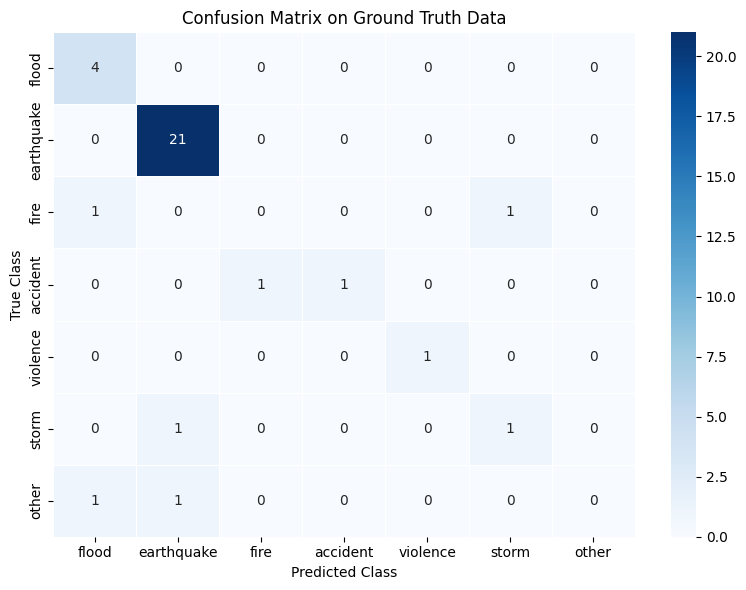

In [6]:
# Classification Report & Confusion Matrix
y_true = eval_df['true_class']
y_pred = eval_df['predicted_class']

print('\n=== GLOBAL CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, labels=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix on Ground Truth Data')
plt.ylabel('True Class'); plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/figures/final_confusion_matrix.png', dpi=150)
plt.show()

In [7]:
# Load Model for SHAP Explainability
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import shap

print('Loading fine-tuned model for SHAP analysis...')
try:
    tokenizer = AutoTokenizer.from_pretrained(f'{MODELS_DIR}/crisis_classifier/tokenizer')
    model = AutoModelForSequenceClassification.from_pretrained(f'{MODELS_DIR}/crisis_classifier/model_weights')
    device = 0 if torch.cuda.is_available() else -1
    pred_pipeline = pipeline('text-classification', model=model, tokenizer=tokenizer, return_all_scores=True, device=device)
    print(' Model loaded successfully.')
    can_run_shap = True
except Exception as e:
    print(f' Could not load fine-tuned model: {e}')
    can_run_shap = False

Loading fine-tuned model for SHAP analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Model loaded successfully.


In [8]:
if can_run_shap:
    print('Generating SHAP explanations for top confident predictions...')
# Pick a few highly confident predictions across different classes
    sample_df = df_clf[df_clf['classification_status'] == 'classified'].sort_values('confidence_score', ascending=False)

# Get one sample per class
    texts_to_explain = []
    for c in CLASS_NAMES:
        c_df = sample_df[sample_df['predicted_class'] == c]
        if len(c_df) > 0:
# Limit the text length to avoid excessive computation for SHAP
# A common practice is to truncate text for SHAP if it's very long
            texts_to_explain.append(c_df.iloc[0]['text_cleaned'][:256]) # Limiting to first 256 characters

    if len(texts_to_explain) > 0:
# Check for the number of texts before proceeding with SHAP calculation
        if len(texts_to_explain) > 5:
            print(f"Warning: Attempting to explain {len(texts_to_explain)} texts. This might take a long time.")
            print("Consider reducing the number of samples for SHAP analysis if you continue to face issues.")

        print(f"Explaining {len(texts_to_explain)} sample texts for SHAP analysis.")
        explainer = shap.Explainer(pred_pipeline)
        shap_values = explainer(texts_to_explain)

# Visualize the first explanation
        print(f"\nExplanation for: {texts_to_explain[0][:100]}...")
        shap.plots.text(shap_values[0])

# Visualize the second explanation if available
        if len(texts_to_explain) > 1:
            print(f"\nExplanation for: {texts_to_explain[1][:100]}...")
            shap.plots.text(shap_values[1])
    else:
        print('No confident texts to explain.')
else:
    print('Skipping SHAP due to missing model.')

Generating SHAP explanations for top confident predictions...
Consider reducing the number of samples for SHAP analysis if you continue to face issues.
Explaining 7 sample texts for SHAP analysis.


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  14%|█▍        | 1/7 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  43%|████▎     | 3/7 [03:15<02:57, 44.39s/it]

...

PartitionExplainer explainer: 100%|██████████| 7/7 [08:48<00:00, 78.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 8it [11:12, 96.06s/it]



Explanation for: [MetroTV] Banjir melanda 15 kelurahan di Jakarta Barat dan Jakarta Selatan, ribuan warga mengungsi k...



Explanation for: Earthquake M5.3 at depth 10 km in 215 km BaratLaut TAHUNA-KEP.SANGIHE-SULUT....


=== CLUSTERING PIPELINE STATS ===
Total input posts: 75
Posts clustered into events: 2
Singletons / Noise: 73
Total canonical events generated: 51


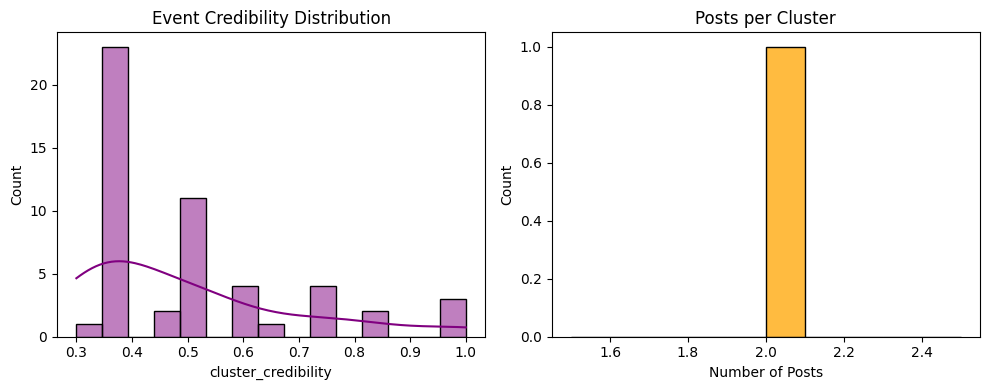

In [9]:
# Evaluate Clustering Pipeline
master_events = pd.read_csv(f'{DATA_PROCESSED}/master_events.csv', index_col='post_id')
clustered_events = pd.read_csv(f'{DATA_PROCESSED}/clustered_events.csv')

print('=== CLUSTERING PIPELINE STATS ===')
print(f'Total input posts: {len(master_events)}')
unassigned = (master_events['cluster_id'] == -1).sum()
print(f'Posts clustered into events: {len(master_events) - unassigned}')
print(f'Singletons / Noise: {unassigned}')
print(f'Total canonical events generated: {len(clustered_events)}')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(clustered_events['cluster_credibility'], bins=15, kde=True, color='purple')
plt.title('Event Credibility Distribution')

plt.subplot(1,2,2)
event_sizes = master_events[master_events['cluster_id'] != -1]['cluster_id'].value_counts()
if len(event_sizes) > 0:
    sns.histplot(event_sizes, bins=10, color='orange')
    plt.title('Posts per Cluster')
    plt.xlabel('Number of Posts')
else:
    plt.text(0.5, 0.5, 'No multi-post clusters', ha='center', va='center')
    plt.title('Posts per Cluster')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/figures/clustering_stats.png', dpi=150)
plt.show()

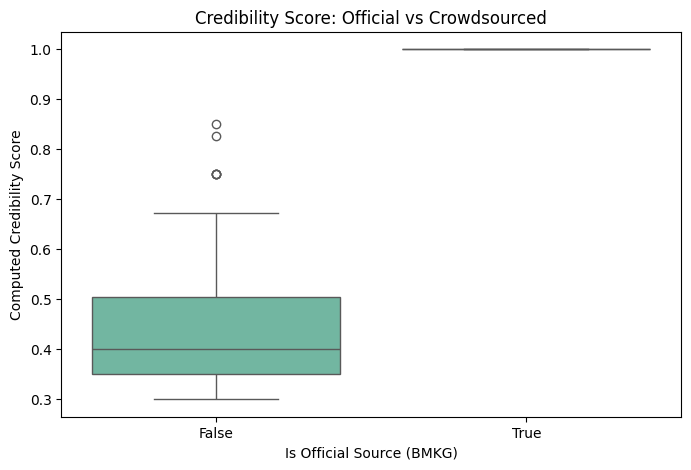

Mean Credibility by Source:
source_platform
bmkg         1.000000
telegram     0.716279
crisisnlp    0.600000
reddit       0.397099
news_rss     0.392857
Name: credibility_score, dtype: float64


In [10]:
# Credibility vs Verification Rate
# Check if BMKG (ground truth proxy) aligns with high credibility scores
master_events['is_official'] = master_events['source_platform'] == 'bmkg'

plt.figure(figsize=(8,5))
sns.boxplot(data=master_events, x='is_official', y='credibility_score', palette='Set2')
plt.title('Credibility Score: Official vs Crowdsourced')
plt.xlabel('Is Official Source (BMKG)')
plt.ylabel('Computed Credibility Score')
plt.savefig(f'{OUTPUTS_DIR}/figures/credibility_vs_official.png', dpi=150)
plt.show()

print('Mean Credibility by Source:')
print(master_events.groupby('source_platform')['credibility_score'].mean().sort_values(ascending=False))